# FinOps anti-pattern case: naive migration to Spark without architectural optimization

This notebook demonstrates the **wrong way** to migrate to a distributed Spark architecture:

- no FinOps redesign
- no storage lifecycle optimization
- no autoscaling optimization
- no reduction of logging or network traffic
- **entire S3 volume** copied into **HDFS**
- model retraining and metric calculation run on the **full dataset**

The goal is to show that **distributed computing by itself does not reduce cost**.  
If Spark is introduced as a pure lift-and-shift, total spend can **increase significantly**.


## 1. Current baseline

Current monthly bill:

- **EC2 (GPU) compute**: $12,000 — `4 x p3.8xlarge`, 24/7
- **S3 storage**: $3,500 — everything in Standard, no lifecycle
- **Data transfer**: $2,000 — cross-AZ + egress
- **Kubernetes nodes**: $4,000 — fixed 8 x m5.2xlarge, no HPA
- **Logging**: $1,500 — DEBUG logs for all services in CloudWatch

### Important baseline assumption
In the current setup the model is trained only on the **active working set**.  
This means the current bill does **not** reflect full-dataset retraining over the whole historical volume.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

current_bill = pd.DataFrame([
    {"component": "EC2 GPU", "category": "compute", "monthly_cost_usd": 12000, "notes": "4 x p3.8xlarge, 24/7"},
    {"component": "S3", "category": "storage", "monthly_cost_usd": 3500, "notes": "All data in Standard, no lifecycle"},
    {"component": "Data transfer", "category": "network", "monthly_cost_usd": 2000, "notes": "Cross-AZ + egress"},
    {"component": "Kubernetes nodes", "category": "compute", "monthly_cost_usd": 4000, "notes": "Fixed 8 x m5.2xlarge, no HPA"},
    {"component": "Logging", "category": "observability", "monthly_cost_usd": 1500, "notes": "DEBUG logs in CloudWatch"},
])

current_bill

,component,category,monthly_cost_usd,notes
0,EC2 GPU,compute,12000,"4 x p3.8xlarge, 24/7"
1,S3,storage,3500,"All data in Standard, no lifecycle"
2,Data transfer,network,2000,Cross-AZ + egress
3,Kubernetes nodes,compute,4000,"Fixed 8 x m5.2xlarge, no HPA"
4,Logging,observability,1500,DEBUG logs in CloudWatch


In [2]:
current_total = current_bill["monthly_cost_usd"].sum()
current_total

np.int64(23000)

## 2. Naive target state: “move everything to Spark as-is”

This anti-pattern migration does the following:

1. Keeps the old infrastructure cost profile conceptually intact  
2. Adds a Spark cluster on top  
3. Copies the **entire S3 history** into HDFS  
4. Retrains the model on the **entire dataset**, not only the active working set  
5. Calculates metrics on the **entire volume**
6. Does not introduce lifecycle, autoscaling, log reduction, or network redesign

### Consequence
The platform becomes **more expensive** because:
- Spark adds a new compute/storage layer
- HDFS stores a replicated copy of all historical data
- training and evaluation scope expands from active data to full history


In [3]:
assumptions = {
    # Back-calculate approximate S3 volume from the monthly S3 bill
    "s3_standard_price_per_gib_month": 0.023,

    # Current training uses only active working set
    "current_active_working_set_ratio": 0.15,

    # Naive Spark migration copies full S3 volume to HDFS
    "naive_hdfs_fraction_of_s3": 1.0,

    # HDFS design
    "hdfs_replication_factor": 3,
    "hdfs_free_space_reserve_ratio": 0.15,

    # Cost scaling assumptions for naive lift-and-shift
    # GPU cost grows because now training + metrics are run over the whole historical volume
    "gpu_training_expansion_factor": 2.4,

    # Existing k8s/application estate remains, and Spark CPU cluster is added on top
    "existing_k8s_cost_multiplier": 1.0,
    "new_spark_cpu_cluster_monthly_cost_usd": 5500,

    # HDFS full-history cluster
    "hdfs_full_history_monthly_cost_usd": 9800,

    # Network rises because of data ingestion into HDFS + shuffle + unchanged cross-AZ layout
    "network_cost_multiplier": 1.8,

    # Logging rises because Spark/HDFS/services add more DEBUG/infra logs
    "logging_cost_multiplier": 1.7,

    # Control-plane and support services for Spark/HDFS
    "spark_hdfs_control_plane_monthly_cost_usd": 900,
}
pd.Series(assumptions)

s3_standard_price_per_gib_month                 0.023
current_active_working_set_ratio                0.150
naive_hdfs_fraction_of_s3                       1.000
hdfs_replication_factor                         3.000
hdfs_free_space_reserve_ratio                   0.150
gpu_training_expansion_factor                   2.400
existing_k8s_cost_multiplier                    1.000
new_spark_cpu_cluster_monthly_cost_usd       5500.000
hdfs_full_history_monthly_cost_usd           9800.000
network_cost_multiplier                         1.800
logging_cost_multiplier                         1.700
spark_hdfs_control_plane_monthly_cost_usd     900.000
dtype: float64

## 3. Reconstruct dataset volume and compare training scope

We estimate the total S3 volume from the storage bill and compare:

- current state: training on **active working set only**
- naive Spark state: retraining and metrics on **full historical volume**


In [4]:
estimated_s3_gib = current_bill.loc[current_bill["component"] == "S3", "monthly_cost_usd"].iloc[0] / assumptions["s3_standard_price_per_gib_month"]
estimated_s3_tib = estimated_s3_gib / 1024

current_active_tib = estimated_s3_tib * assumptions["current_active_working_set_ratio"]
naive_full_hdfs_logical_tib = estimated_s3_tib * assumptions["naive_hdfs_fraction_of_s3"]
naive_full_hdfs_raw_tib = naive_full_hdfs_logical_tib * assumptions["hdfs_replication_factor"] / (1 - assumptions["hdfs_free_space_reserve_ratio"])

scope_df = pd.DataFrame([
    {"metric": "Estimated total S3 volume", "value_tib": estimated_s3_tib},
    {"metric": "Current active working set used for training", "value_tib": current_active_tib},
    {"metric": "Naive Spark logical HDFS volume", "value_tib": naive_full_hdfs_logical_tib},
    {"metric": "Naive Spark raw HDFS capacity needed", "value_tib": naive_full_hdfs_raw_tib},
])

scope_df["value_tib"] = scope_df["value_tib"].round(2)
scope_df

,metric,value_tib
0,Estimated total S3 volume,148.61
1,Current active working set used for training,22.29
2,Naive Spark logical HDFS volume,148.61
3,Naive Spark raw HDFS capacity needed,524.50


### Interpretation

This is the core change in the scenario:

- **before**: model training uses only a limited active subset  
- **after naive migration**: full historical S3 is copied to HDFS and reused for training and metric computation

So Spark is not just a new execution engine here.  
It is also expanding the **data scope**, which increases compute, storage, and network demand.


## 4. Planned naive Spark configuration

This is intentionally **not optimized**.

### Planned configuration
- Existing application/Kubernetes estate remains
- Add fixed Spark CPU cluster
- Add fixed/overprovisioned GPU Spark workers
- Add HDFS sized for the **entire S3 history**
- Keep S3 Standard unchanged
- Keep DEBUG logging unchanged
- Keep network topology unchanged


In [5]:
naive_config = pd.DataFrame([
    {"layer": "Existing GPU estate", "configuration": "Keep current GPU baseline and expand workload scope", "reason": "Retraining on full history increases GPU usage"},
    {"layer": "Existing Kubernetes nodes", "configuration": "Keep 8 fixed nodes", "reason": "No redesign, no HPA, old platform still exists"},
    {"layer": "Spark CPU cluster", "configuration": "Add dedicated fixed Spark compute pool", "reason": "Distributed ETL + metrics over full data"},
    {"layer": "Spark GPU workers", "configuration": "Add/expand GPU execution for distributed training", "reason": "Training and evaluation on all data"},
    {"layer": "HDFS cluster", "configuration": f"Store full S3 history; raw target ~{naive_full_hdfs_raw_tib:.1f} TiB", "reason": "Copy entire lake into HDFS"},
    {"layer": "S3", "configuration": "Keep all data in Standard", "reason": "No lifecycle optimization"},
    {"layer": "Logging", "configuration": "Keep DEBUG + add Spark/HDFS logs", "reason": "No observability optimization"},
])

naive_config

,layer,configuration,reason
0,Existing GPU estate,Keep current GPU baseline and expand workload ...,Retraining on full history increases GPU usage
1,Existing Kubernetes nodes,Keep 8 fixed nodes,"No redesign, no HPA, old platform still exists"
2,Spark CPU cluster,Add dedicated fixed Spark compute pool,Distributed ETL + metrics over full data
3,Spark GPU workers,Add/expand GPU execution for distributed training,Training and evaluation on all data
4,HDFS cluster,Store full S3 history; raw target ~524.5 TiB,Copy entire lake into HDFS
5,S3,Keep all data in Standard,No lifecycle optimization
6,Logging,Keep DEBUG + add Spark/HDFS logs,No observability optimization


## 5. Example HDFS sizing for the naive full-history approach

Assume each HDFS DataNode contributes **10 TiB raw**.


In [6]:
raw_tib_per_hdfs_node = 10
required_hdfs_datanodes = math.ceil(naive_full_hdfs_raw_tib / raw_tib_per_hdfs_node)

hdfs_layout = pd.DataFrame([
    {"role": "NameNode", "count": 1, "raw_tib_each": 0, "total_raw_tib": 0},
    {"role": "Standby NameNode", "count": 1, "raw_tib_each": 0, "total_raw_tib": 0},
    {"role": "Journal/coordination nodes", "count": 3, "raw_tib_each": 0, "total_raw_tib": 0},
    {"role": "DataNode", "count": required_hdfs_datanodes, "raw_tib_each": raw_tib_per_hdfs_node, "total_raw_tib": required_hdfs_datanodes * raw_tib_per_hdfs_node},
])

hdfs_layout

,role,count,raw_tib_each,total_raw_tib
0,NameNode,1,0,0
1,Standby NameNode,1,0,0
2,Journal/coordination nodes,3,0,0
3,DataNode,53,10,530


## 6. Cost model of the naive migration

We build the new bill with the following logic:

- **GPU cost increases** because training expands from active subset to full history
- **Old Kubernetes cost remains**
- **Spark CPU cluster is added** as a new line item
- **HDFS cluster is added** for full-history storage
- **S3 cost stays unchanged**
- **Network cost increases**
- **Logging cost increases**


In [7]:
naive_bill = pd.DataFrame([
    {"component": "GPU training/inference estate", "category": "compute", "monthly_cost_usd": round(12000 * assumptions["gpu_training_expansion_factor"], 0),
     "driver": "Full-history retraining + metrics instead of active working set"},
    {"component": "Existing Kubernetes nodes", "category": "compute", "monthly_cost_usd": round(4000 * assumptions["existing_k8s_cost_multiplier"], 0),
     "driver": "Legacy platform kept without optimization"},
    {"component": "Spark CPU cluster", "category": "compute", "monthly_cost_usd": assumptions["new_spark_cpu_cluster_monthly_cost_usd"],
     "driver": "Distributed processing over full dataset"},
    {"component": "HDFS cluster", "category": "storage/compute", "monthly_cost_usd": assumptions["hdfs_full_history_monthly_cost_usd"],
     "driver": "Full historical data copied into replicated HDFS"},
    {"component": "S3 Standard", "category": "storage", "monthly_cost_usd": 3500,
     "driver": "No lifecycle, no tiering, original storage retained"},
    {"component": "Data transfer", "category": "network", "monthly_cost_usd": round(2000 * assumptions["network_cost_multiplier"], 0),
     "driver": "Extra ingestion, shuffle, and unchanged cross-AZ traffic"},
    {"component": "Logging", "category": "observability", "monthly_cost_usd": round(1500 * assumptions["logging_cost_multiplier"], 0),
     "driver": "More platform logs, still DEBUG-heavy"},
    {"component": "Spark/HDFS control plane", "category": "platform", "monthly_cost_usd": assumptions["spark_hdfs_control_plane_monthly_cost_usd"],
     "driver": "Metadata, cluster services, coordination"},
])

naive_bill

,component,category,monthly_cost_usd,driver
0,GPU training/inference estate,compute,28800.0,Full-history retraining + metrics instead of a...
1,Existing Kubernetes nodes,compute,4000.0,Legacy platform kept without optimization
2,Spark CPU cluster,compute,5500.0,Distributed processing over full dataset
3,HDFS cluster,storage/compute,9800.0,Full historical data copied into replicated HDFS
4,S3 Standard,storage,3500.0,"No lifecycle, no tiering, original storage ret..."
5,Data transfer,network,3600.0,"Extra ingestion, shuffle, and unchanged cross-..."
6,Logging,observability,2550.0,"More platform logs, still DEBUG-heavy"
7,Spark/HDFS control plane,platform,900.0,"Metadata, cluster services, coordination"


In [8]:
naive_total = naive_bill["monthly_cost_usd"].sum()
increase_abs = naive_total - current_total
increase_pct = increase_abs / current_total

summary = pd.DataFrame([
    {"metric": "Current monthly bill", "value_usd": current_total},
    {"metric": "Naive Spark monthly bill", "value_usd": naive_total},
    {"metric": "Monthly cost increase", "value_usd": increase_abs},
    {"metric": "Increase ratio", "value_usd": increase_pct},
])

summary

,metric,value_usd
0,Current monthly bill,23000.00
1,Naive Spark monthly bill,58650.00
2,Monthly cost increase,35650.00
3,Increase ratio,1.55


## 7. Comparison: before vs naive Spark lift-and-shift


In [9]:
comparison = pd.DataFrame([
    {"scenario": "Current architecture", "monthly_cost_usd": current_total},
    {"scenario": "Naive Spark migration", "monthly_cost_usd": naive_total},
])

comparison

,scenario,monthly_cost_usd
0,Current architecture,23000.0
1,Naive Spark migration,58650.0


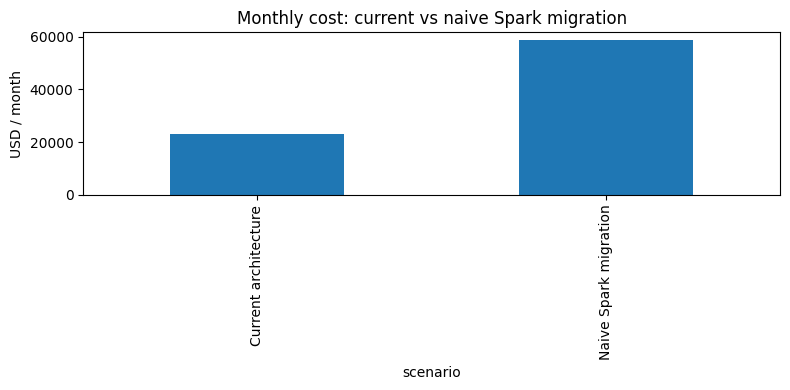

In [10]:
comparison.plot(kind="bar", x="scenario", y="monthly_cost_usd", legend=False, figsize=(8, 4), title="Monthly cost: current vs naive Spark migration")
plt.ylabel("USD / month")
plt.tight_layout()
plt.show()

In [11]:
growth_breakdown = pd.DataFrame([
    {"driver": "Training scope expansion", "impact": "GPU cost rises because full history is used instead of active working set"},
    {"driver": "New Spark CPU layer", "impact": "Distributed compute is added without removing old baseline"},
    {"driver": "Full-history HDFS", "impact": "Replicated storage cluster appears as a large new cost line"},
    {"driver": "Network growth", "impact": "Extra ingestion and shuffle amplify traffic costs"},
    {"driver": "Observability growth", "impact": "Spark/HDFS logs increase ingestion and retention cost"},
])

growth_breakdown

,driver,impact
0,Training scope expansion,GPU cost rises because full history is used in...
1,New Spark CPU layer,Distributed compute is added without removing ...
2,Full-history HDFS,Replicated storage cluster appears as a large ...
3,Network growth,Extra ingestion and shuffle amplify traffic costs
4,Observability growth,Spark/HDFS logs increase ingestion and retenti...


## 8. Sensitivity analysis

We vary two assumptions:

- how much GPU cost grows after moving from active-set training to full-history training
- how expensive the HDFS full-history cluster becomes


In [12]:
gpu_growth_options = np.array([1.8, 2.2, 2.6, 3.0])
hdfs_cost_options = np.array([7000, 9000, 11000, 13000])

rows = []
for gpu_growth in gpu_growth_options:
    for hdfs_cost in hdfs_cost_options:
        total = (
            12000 * gpu_growth +
            4000 +
            assumptions["new_spark_cpu_cluster_monthly_cost_usd"] +
            hdfs_cost +
            3500 +
            2000 * assumptions["network_cost_multiplier"] +
            1500 * assumptions["logging_cost_multiplier"] +
            assumptions["spark_hdfs_control_plane_monthly_cost_usd"]
        )
        rows.append({
            "gpu_growth_factor": gpu_growth,
            "hdfs_cost_usd": hdfs_cost,
            "monthly_total_usd": round(total, 0),
            "increase_pct": round((total - current_total) / current_total, 4)
        })

sensitivity = pd.DataFrame(rows)
sensitivity.head()

,gpu_growth_factor,hdfs_cost_usd,monthly_total_usd,increase_pct
0,1.8,7000,48650.0,1.1152
1,1.8,9000,50650.0,1.2022
2,1.8,11000,52650.0,1.2891
3,1.8,13000,54650.0,1.3761
4,2.2,7000,53450.0,1.3239


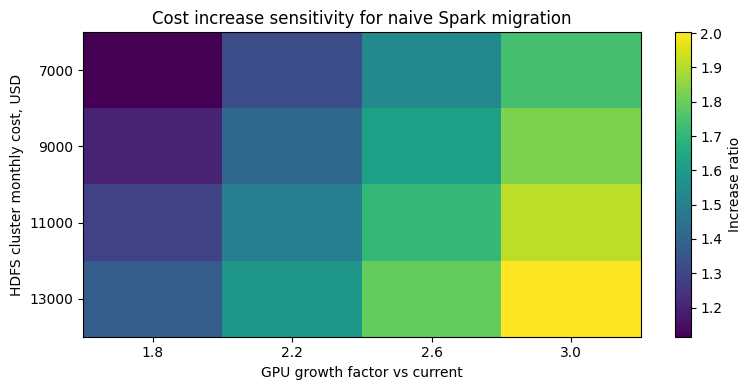

In [13]:
pivot = sensitivity.pivot(index="hdfs_cost_usd", columns="gpu_growth_factor", values="increase_pct")
plt.figure(figsize=(8, 4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), [f"{c:.1f}" for c in pivot.columns])
plt.yticks(range(len(pivot.index)), [f"{int(i)}" for i in pivot.index])
plt.xlabel("GPU growth factor vs current")
plt.ylabel("HDFS cluster monthly cost, USD")
plt.title("Cost increase sensitivity for naive Spark migration")
plt.colorbar(label="Increase ratio")
plt.tight_layout()
plt.show()

## 9. Final conclusion

This notebook shows a classic FinOps anti-pattern:

> **A distributed architecture is introduced, but the workload scope expands and the old inefficiencies remain.**

### Result
Instead of reducing cost, the organization gets:

- duplicated storage layers
- larger training scope
- more infrastructure
- more traffic
- more logs
- higher total spend

### Teaching takeaway
Spark should be presented not as “a way to parallelize everything”, but as a technology that needs:

- scope control
- data-temperature strategy
- lifecycle design
- scaling policy
- cost ownership


## 10. Suggested classroom discussion

1. Why does the bill rise even though Spark is “more powerful”?  
2. Which part of the cost growth comes from Spark itself, and which part comes from **scope expansion**?  
3. At what point is full-history retraining justified by model quality?  
4. What measurements must be collected before deciding that HDFS should store the whole lake?
